In [1]:
import numpy as np
import pandas as pd
import sys
import matplotlib.pyplot as plt
sys.path.append('../')
from Scattering_Simulator import pairwise_method
from scipy import integrate
import matplotlib.cm as cm
from scipy.spatial.transform import Rotation as R
from gsd import hoomd
from scipy.interpolate import BSpline, splrep
from scipy.signal import savgol_filter
import os

## HOOMD-blue to SAXS
The purpose of this notebook is to convert HOOMD-blue simulations into SAXS curves that are directly comparble to SAXS data obtained experimentally. This is done first by extracting the positions and orientations of objects from the HOOMD-blue simulation file (.gsd file) and creating a model of the object being simulated (e.g., spheres, cubes). Then this information is used with the MC-DFM to simulate the scattering curve at any frame of the simulation. The following section is used to read the .gsd file and extract the positions and orientations. 

In [2]:
def extract_positions_orientations(filename):
    """
    Extract positions and orientations from each frame of a GSD file.

    Parameters
    ----------
    filename : str
        Path to the GSD trajectory file.

    Returns
    -------
    positions : list of np.ndarray
        List of arrays of shape (N, 3) with particle positions per frame.
    orientations : list of np.ndarray or None
        List of arrays of shape (N, 4) with quaternions per frame,
        or None if not present in the frame.
    """
    traj = hoomd.open(name=filename, mode='r')

    positions = []
    orientations = []

    for frame in traj:
        positions.append(frame.particles.position.copy())

        if hasattr(frame.particles, 'orientation'):
            orientations.append(frame.particles.orientation.copy())
        else:
            orientations.append(None)

    return positions, orientations


def quaternion_to_euler(quat, degrees=True, order='xyz'):
    """
    Convert a quaternion (HOOMD format: [qw, qx, qy, qz]) to Euler angles.

    Parameters:
    - quat: array-like, quaternion [qw, qx, qy, qz]
    - degrees: bool, return angles in degrees if True (default), radians if False
    - order: str, axes sequence for Euler angles ('xyz', 'zyx', etc.)

    Returns:
    - tuple of 3 Euler angles (angle_x, angle_y, angle_z)
    """
    # Convert to scipy format (qx, qy, qz, qw)
    #scipy_quat = [quat[1], quat[2], quat[3], quat[0]]
    scipy_quat = quat
    r = R.from_quat(scipy_quat)
    angles = r.as_euler(order, degrees=degrees)
    return angles

In [3]:
file_path = '../Data/HOOMD/N8000.0_phi0.010_epsd7.10_delta0.25_epsY0.73_lamb4.28.gsd' #This is the path to the .gsd file 

In [4]:
positions, orientations = extract_positions_orientations(file_path)
print(f"Number of frames: {len(positions)}")
print("First frame position shape:", positions[0].shape)
print("First frame orientation shape:", orientations[0].shape if orientations[0] is not None else "Not available")

Number of frames: 101
First frame position shape: (8000, 3)
First frame orientation shape: (8000, 4)


In [5]:
orientations_euler = []
for i in range(len(orientations)):
    angles = quaternion_to_euler(orientations[i][:, :]) 
    orientations_euler.append(angles)

lattice_coordinates = []
for i in range(len(orientations_euler)):
    lattice_coordinates.append(np.hstack((positions[i][:, :], orientations_euler[i][:, :])))

In [6]:
lattice_coordinates = lattice_coordinates[-1]

## Building Block 
The building block is defined as the object being simulated such as a sphere or cube. This is not saved in the .gsd file so we need to create this object here. 

In [7]:
def grid_points_in_sphere(D, spacing):
    """
    Generate a regular 3D grid of points spaced by 'spacing' that fit inside a sphere.

    Parameters
    ----------
    D : float
        Diameter of the sphere.
    spacing : float
        Distance between adjacent grid points.

    Returns
    -------
    points : np.ndarray of shape (M, 3)
        Grid points inside the sphere.
    """
    radius = D / 2.0
    r2 = radius ** 2

    # Create a 3D grid
    coords = np.arange(-radius, radius + spacing, spacing)
    X, Y, Z = np.meshgrid(coords, coords, coords)
    grid = np.vstack([X.ravel(), Y.ravel(), Z.ravel()]).T

    # Keep only the points inside the sphere
    mask = np.sum(grid**2, axis=1) <= r2
    points = grid[mask]

    return points


def fill_cube_with_points(N, edge_length):
    """
    Fill a cube with N points approximately uniformly distributed.

    Parameters
    ----------
    N : int
        Number of points to place inside the cube.
    edge_length : float
        Length of each edge of the cube.

    Returns
    -------
    points : np.ndarray of shape (N, 3)
        Coordinates of the points inside the cube.
    """
    # Estimate number of points per side of the grid
    n_side = int(np.ceil(N ** (1/3)))
    spacing = edge_length / n_side

    # Create grid
    coords = np.linspace(-edge_length / 2 + spacing / 2,
                          edge_length / 2 - spacing / 2,
                          n_side)

    X, Y, Z = np.meshgrid(coords, coords, coords)
    grid = np.vstack([X.ravel(), Y.ravel(), Z.ravel()]).T

    # Select only the first N points
    points = grid[:N]

    return points

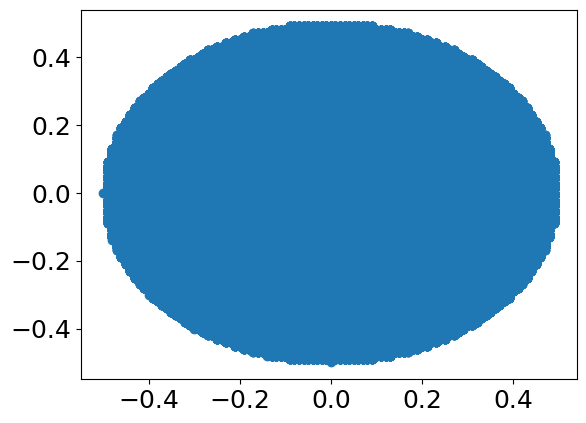

In [65]:
#Sphere
D = 1            # diameter of the sphere
spacing = D/100    # spacing between grid points
points = grid_points_in_sphere(D, spacing)

#Cube
#points = fill_cube_with_points(N=100000, edge_length=0.1)

ones = np.array([1]*len(points))
points = np.hstack((points, ones.reshape(-1,1)))
plt.scatter(points[:,0], points[:,2])
plt.show()

## Calculate the Scattering curve 
This next section reads the positions and orientations from the simulation frames of the .gsd file and calculates the scattering curve of the specified frame. 

In [66]:
filename = '../Data/HOOMD/structure_factor_summary_excel.xlsx'
data_excel = pd.read_excel(filename).values

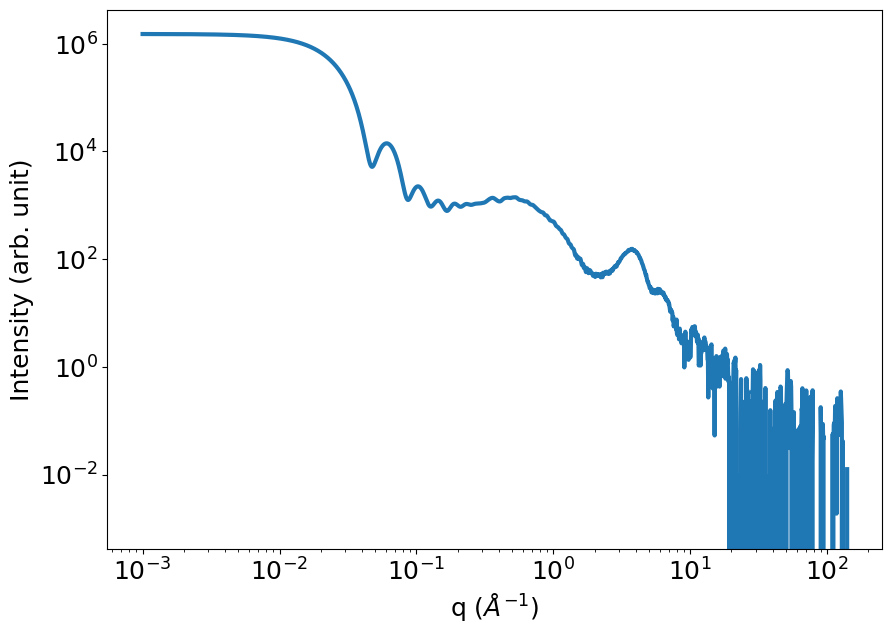

In [67]:

################################## INPUTS ##########################################################################################

plot_every_n_frame = 5            # Determines how many SAXS simulations occur per frame  
histogram_bins = 10000            # Number of bins in the pairwise distribution calculation 
q = np.geomspace(0.001, 140, 2000)  # SAXS q-range to be calculated
path = '../Data/HOOMD/core_shell_cube_assembly_0.1_edge_length/assembly_2/'  # Where to save the files and plot

####################################################################################################################################

plt.rcParams.update({'font.size': 18})
fig, ax = plt.subplots(figsize=(10,7))

n_samples = 5000000
simulator = pairwise_method.scattering_simulator(n_samples)
simulator.sample_building_block(points)
simulator.sample_lattice_coordinates(lattice_coordinates)
simulator.calculate_structure_coordinates()
# I_q = simulator.simulate_multiple_scattering_curves_lattice_coords(points, lattice_coordinates[i], histogram_bins, q, save=False).numpy()
# I_q = np.mean(I_q, axis=1)
I_q = simulator.simulate_scattering_curve_fast_lattice(points, lattice_coordinates, histogram_bins, q, save=False).numpy()
plt.rcParams.update({'font.size': 18})        
ax.plot(q, I_q, linewidth = 3, label = '10m Sample Size')
#ax.scatter(data_excel[:,1], data_excel[:,0], linewidth = 3, label = '10m Sample Size')
ax.set_yscale('log')
ax.set_xscale('log')
ax.set_ylabel('Intensity (arb. unit)')
ax.set_xlabel('q ($\\AA^{-1}$)')
#plt.legend(fontsize=14)
data = np.hstack((q.reshape(-1,1), I_q.reshape(-1,1)))
#np.save(path + scattering_curve_' + str(i) + '.npy', data)   
#plt.savefig(path + scattering_curve_plot.png', dpi=600, bbox_inches="tight")

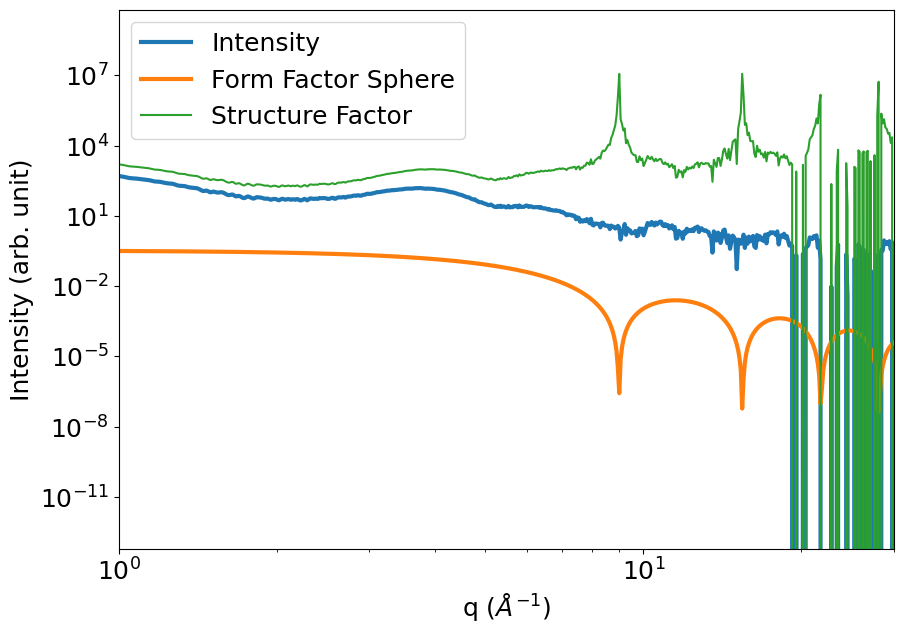

In [69]:
#Analytical Solution of a Sphere
def sphere(q, r):
    return 3*(np.sin(q*r) - q*r*np.cos(q*r))**2/(q*r)**6
I_sphere = sphere(q, 0.5)


plt.rcParams.update({'font.size': 18})
fig, ax = plt.subplots(figsize=(10,7))

ax.plot(q, I_q, linewidth = 3, label = 'Intensity')
ax.plot(q, I_sphere, linewidth = 3, label = 'Form Factor Sphere')
ax.plot(q, I_q/I_sphere, label='Structure Factor')

ax.set_yscale('log')
ax.set_xscale('log')
ax.set_ylabel('Intensity (arb. unit)')
ax.set_xlabel('q ($\\AA^{-1}$)')
ax.set_xlim([1, 30])
plt.legend()



In [70]:
import numpy as np

def PercusYevickStructureFactor(q, phi):
    q = np.asarray(q)

    alpha = (1 + 2 * phi)**2 / (1 - phi)**4
    beta = -6 * phi * (1 + phi / 2)**2 / (1 - phi)**4
    gamma = 0.5 * phi * (1 + 2 * phi)**2 / (1 - phi)**4

    q_safe = np.where(q == 0, 1e-10, q)

    c = -3 * (
        3 * gamma - beta * q_safe**2 +
        (-3 * gamma + (beta + 6 * gamma) * q_safe**2 - 2 * (alpha + beta + gamma) * q_safe**4) * np.cos(2 * q_safe) +
        q_safe * (-6 * gamma + (alpha + 2 * beta + 4 * gamma) * q_safe**2) * np.sin(2 * q_safe)
    ) / q_safe**6

    S = 1 / (1 - phi * c)
    return S

(0.0, 12.0)

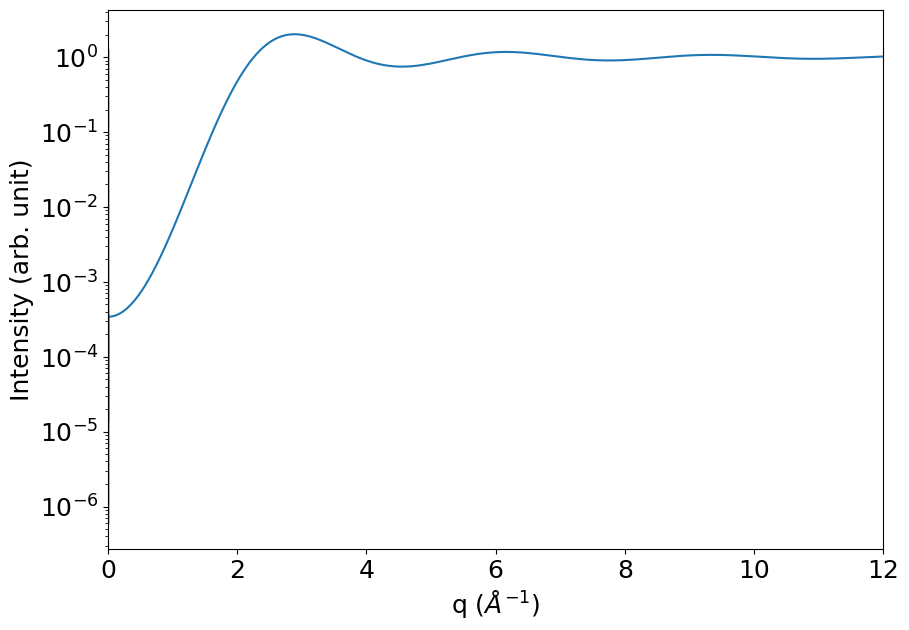

In [71]:
plt.rcParams.update({'font.size': 18})
fig, ax = plt.subplots(figsize=(10,7))


S = PercusYevickStructureFactor(q, 0.01)
# ax.plot(q, I_q, linewidth = 3, label = '10m Sample Size')
# ax.plot(q, I_sphere*1e3, linewidth = 3, label = '10m Sample Size')
#ax.plot(q, I_q/I_sphere, label='Structure Factor')
ax.plot(q, S**1e2)

ax.set_yscale('log')
#ax.set_xscale('log')
ax.set_ylabel('Intensity (arb. unit)')
ax.set_xlabel('q ($\\AA^{-1}$)')
ax.set_xlim([0, 12])


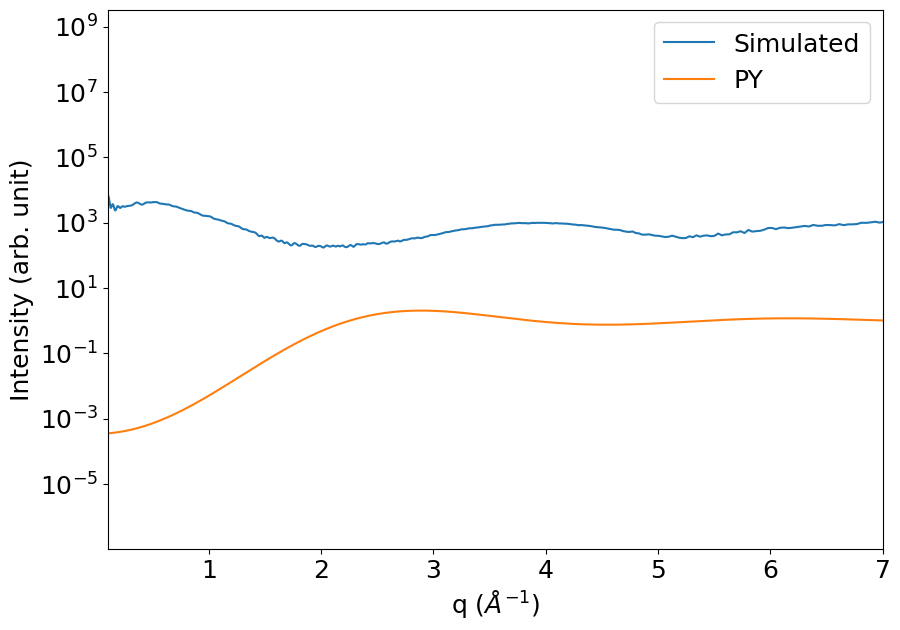

In [89]:
plt.rcParams.update({'font.size': 18})
fig, ax = plt.subplots(figsize=(10,7))


S = percus_yevick_structure_factor(q, 0.01)
# ax.plot(q, I_q, linewidth = 3, label = '10m Sample Size')
# ax.plot(q, I_sphere*1e3, linewidth = 3, label = '10m Sample Size')
ax.plot(q, I_q/I_sphere, label='Simulated')
ax.plot(q*1, S**1e2, label='PY')

ax.set_yscale('log')
#ax.set_xscale('log')
ax.set_ylabel('Intensity (arb. unit)')
ax.set_xlabel('q ($\\AA^{-1}$)')
ax.set_xlim([0.1, 7])
plt.legend()
